前5行数据:
   ID  State Code  County Code  Site Num                      Address  \
0   1           6           37      1103  1630 N MAIN ST, LOS ANGELES   
1   2           6           37      1103  1630 N MAIN ST, LOS ANGELES   
2   3           6           37      1103  1630 N MAIN ST, LOS ANGELES   
3   4           6           37      1103  1630 N MAIN ST, LOS ANGELES   
4   5           6           37      1103  1630 N MAIN ST, LOS ANGELES   

        State       County         City Date Local           O3 Units  \
0  California  Los Angeles  Los Angeles   2006/1/1  Parts per million   
1  California  Los Angeles  Los Angeles   2006/1/1  Parts per million   
2  California  Los Angeles  Los Angeles   2006/1/1  Parts per million   
3  California  Los Angeles  Los Angeles   2006/1/1  Parts per million   
4  California  Los Angeles  Los Angeles   2006/1/2  Parts per million   

    O3 Mean  O3 1st Max Value  O3 1st Max Hour  O3 AQI  
0  0.009625             0.017               16      14  
1

C:\Users\zhman\AppData\Local\Temp\ipykernel_22844\3564963903.py:57: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df_city.groupby(pd.Grouper(key='Date Local', freq='M'))[indicator].mean()


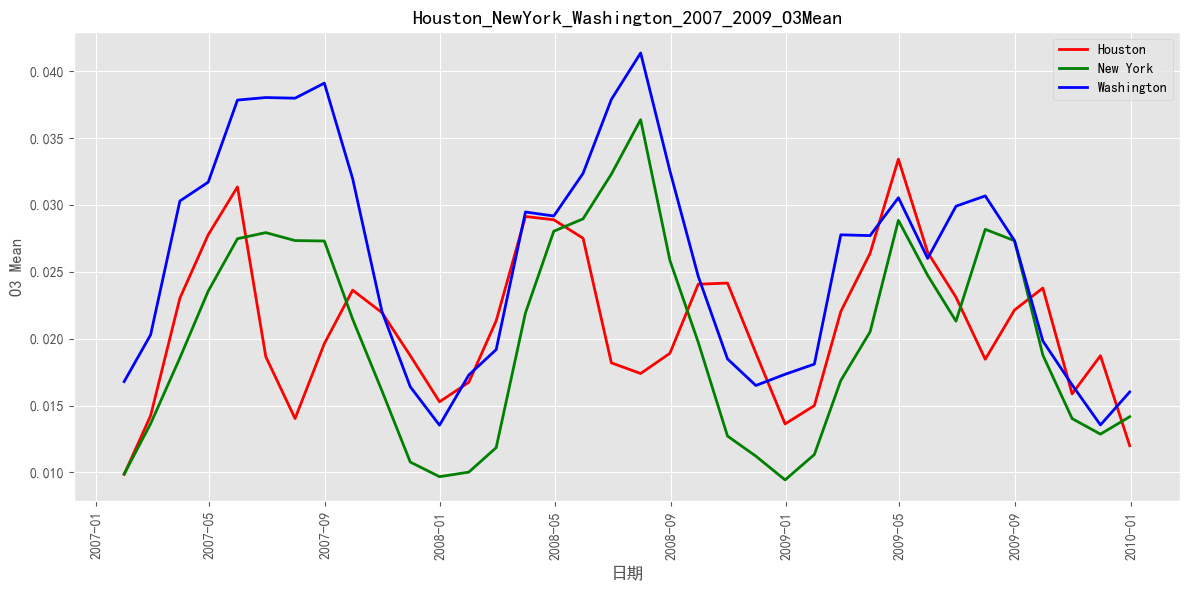

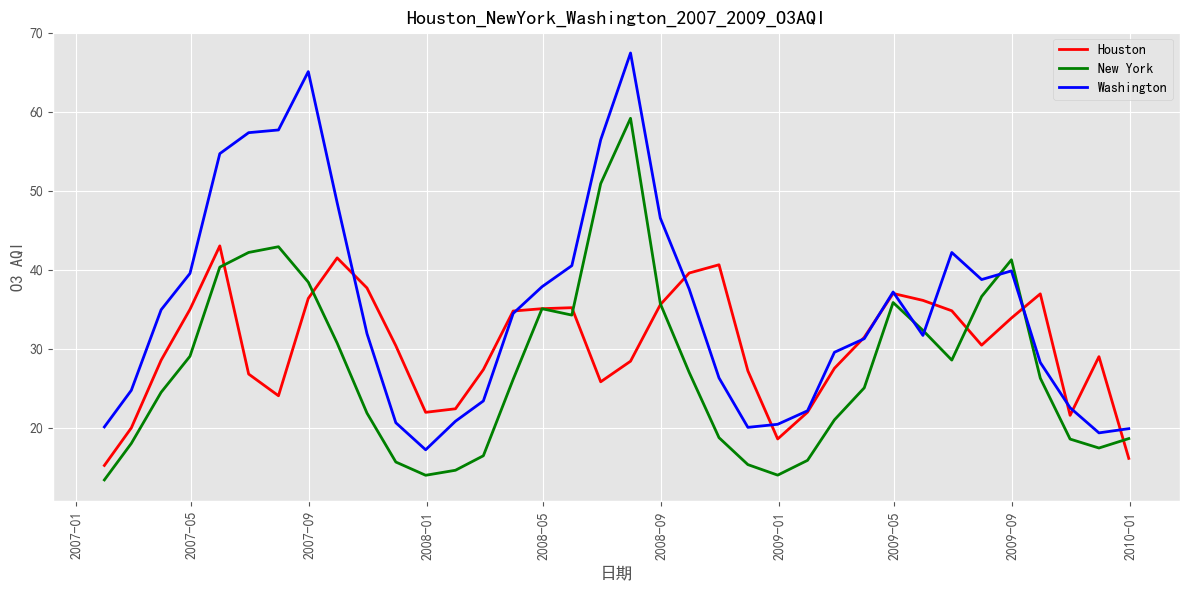

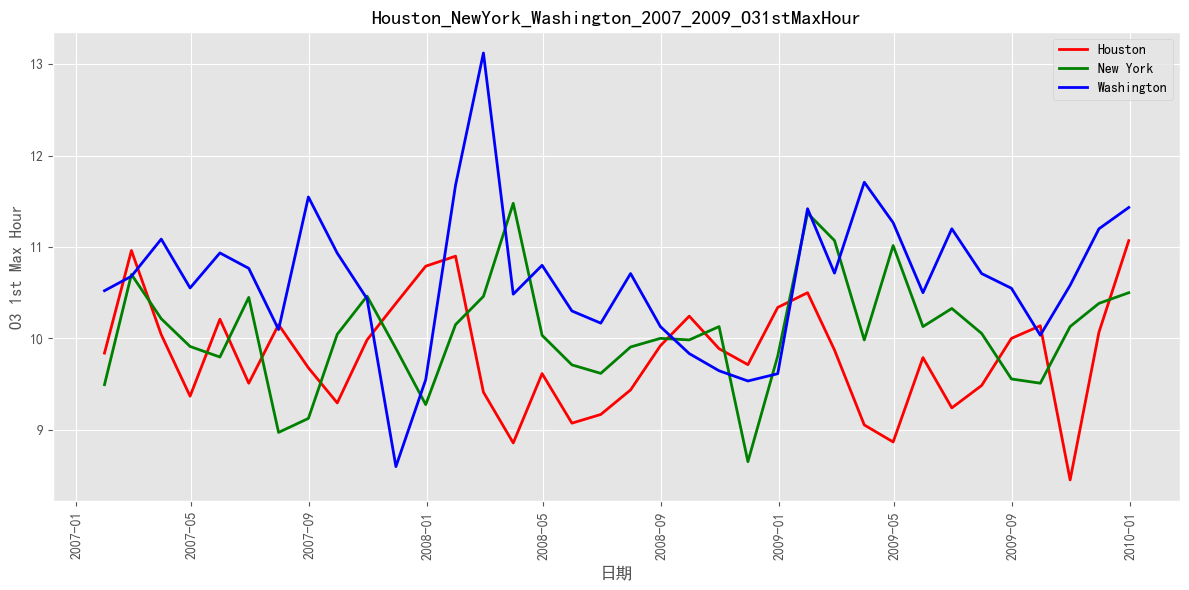

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 设置中文显示
plt.style.use('ggplot')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def main():
    # 任务1和2：数据读取和预处理
    df = pd.read_csv('3.pollution_us_5city_2006_2010_O3.csv')
    print("前5行数据:")
    print(df.head(5))
    print("\n后2行数据:")
    print(df.tail(2))
    
    df['Date Local'] = pd.to_datetime(df['Date Local'])
    df_2007_2009 = df[(df['Date Local'].dt.year >= 2007) & (df['Date Local'].dt.year <= 2009)]
    df_2007_2009 = df_2007_2009.dropna()
    df_2007_2009.to_csv('pollution_us_5city_2007_2009_O3.csv', index=False)
    
    # 任务3：按城市分割数据（修正了参数名）
    df_new = pd.read_csv('pollution_us_5city_2007_2009_O3.csv')
    cities = ['Houston', 'New York', 'Washington']
    
    for city in cities:
        city_df = df_new[df_new['City'] == city]
        txt_file = f'pollution_us_{city}_2007_2009_O3.txt'
        # 修正点：将line_terminator改为lineterminator
        city_df.to_csv(txt_file, sep=' ', index=False, lineterminator='\n')
    
    # 任务4：文本文件转Excel
    for city in cities:
        txt_file = f'pollution_us_{city}_2007_2009_O3.txt'
        excel_file = f'pollution_us_{city}_2007_2009_O3.xlsx'
        pd.read_csv(txt_file, sep=' ').to_excel(excel_file, index=False)
    
    # 任务5：数据可视化
    city_dfs = {}
    for city in cities:
        excel_file = f'pollution_us_{city}_2007_2009_O3.xlsx'
        city_dfs[city] = pd.read_excel(excel_file)
        city_dfs[city]['Date Local'] = pd.to_datetime(city_dfs[city]['Date Local'])
    
    colors = {'Houston': 'red', 'New York': 'green', 'Washington': 'blue'}
    indicators = ['O3 Mean', 'O3 AQI', 'O3 1st Max Hour']
    titles = ['Houston_NewYork_Washington_2007_2009_O3Mean',
              'Houston_NewYork_Washington_2007_2009_O3AQI',
              'Houston_NewYork_Washington_2007_2009_O31stMaxHour']
    
    for indicator, title in zip(indicators, titles):
        plt.figure(figsize=(12, 6))
        
        for city in cities:
            df_city = city_dfs[city]
            monthly_data = df_city.groupby(pd.Grouper(key='Date Local', freq='M'))[indicator].mean()
            plt.plot(monthly_data.index, monthly_data.values, 
                     label=city, color=colors[city], linewidth=2)
        
        plt.title(title)
        plt.xlabel('日期')
        plt.ylabel(indicator)
        plt.xticks(rotation=90)
        plt.legend()
        plt.grid(True)
        
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        
        plt.tight_layout()
        plt.savefig(f'{title}.png')
        plt.show()

if __name__ == '__main__':
    main()